# Bước 05c: Thực nghiệm chọn công thức chuẩn hoá mục tiêu
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

## 1. TỔNG QUAN VÀ MỤC TIÊU

Notebook này trả lời một câu hỏi duy nhất bằng số liệu: **mẫu số chuẩn hoá mục tiêu nên xây
theo cách nào?**

Mục tiêu mà mô hình học không phải sản lượng thô mà là tỷ số `k = y / mẫu_số`. Cách xây mẫu
số quyết định luôn nhãn mà mô hình nhìn thấy, nên phải chọn có căn cứ.

Ba phương án được so trực tiếp:

| Ký hiệu | Mẫu số | Xuất xứ |
|---|---|---|
| `lonij` | phân vị 80 sản lượng đo tại **cùng khung giờ**, trên **15 ngày liền trước** | Lonij et al. (2012), phương trình (18) trong Engerer & Mills (2014) |
| `toan_cuc` | phân vị 99 sản lượng ban ngày trên **toàn tập huấn luyện**, nhân `sin(góc cao Mặt Trời)` | biến thể của dự án |
| `truot_N` | như trên nhưng phân vị tính trên **N ngày liền trước** | phương án lai, để tách riêng ảnh hưởng của độ dài cửa sổ |

Bài báo neo cửa sổ 15 ngày cho dữ liệu của họ. Độ phân giải và bối cảnh dữ liệu dự án khác,
nên notebook **quét lại độ dài cửa sổ từ 7 đến 365 ngày** thay vì mượn con số.

Tài liệu trích dẫn nguyên văn: `docs/2026_08_13_Nguon_Goc_Cong_Thuc_Chuan_Hoa_Muc_Tieu.md`
Toàn văn bài báo: `reports/references/Engerer_Mills_2014_KPV_clear_sky_index_for_photovoltaics.pdf`

**Tính tái lập.** Notebook chỉ đọc từ `05_selected`, không import gì từ pipeline. Hạt giống
cố định, LightGBM chạy chế độ tất định trên CPU. Mục 9 chạy lại một cấu hình hai lần và đối
chiếu để chứng minh hai lần chạy cho đúng cùng một con số.

## 2. Import thư viện và khai báo tham số

In [2]:
# ── Gioi han thread truoc khi numpy nap, giong cac notebook khac trong pipeline ──
import os

for _bien in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
              'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_bien, '6')

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Duong dan ──
SELECTED_DIR = '../../data/model/v5/05_selected'
OUTPUT_DIR = '../../data/model/v5/05c_thuc_nghiem_mau_so'
HINH_DIR = f'{OUTPUT_DIR}/hinh'
os.makedirs(HINH_DIR, exist_ok=True)

# ── Tham so co dinh de tai lap ──
SEED = 42
HORIZON_STEPS = 1              # tam du bao 15 phut
EPS_ELEV = 0.05                # nguong sin(goc cao) coi la ban ngay
PHAN_VI_QUY_MO = 0.99          # phan vi tinh quy mo tram cho phuong an cua du an
PHAN_VI_LONIJ = 0.80           # phan vi cua bai bao
SO_NGAY_LONIJ = 15             # cua so cua bai bao
PHAN_VI_CLIP = 0.99            # nguong cat suy tu phan bo k tren tap TRAIN
CAC_CUA_SO = [7, 15, 30, 60, 90, 180, 365]
TRAM_LOAI_TRU = [19, 24]

SITE_COL, TIMESTAMP_COL, TARGET_COL = 'site_id', 'timestamp', 'energy_generated_kwh'

# Sieu tham so LightGBM giu NGUYEN cho moi phuong an - chi mau so thay doi
THAM_SO_LGB = dict(
    objective='l1', n_estimators=800, learning_rate=0.05, num_leaves=160,
    min_child_samples=30, subsample=0.9, colsample_bytree=0.9,
    random_state=SEED, verbosity=-1, n_jobs=6, max_bin=127,
    force_col_wise=True, deterministic=True,
)

print('Da import thu vien va khai bao tham so.')
print(f'- Doc tu        : {SELECTED_DIR}')
print(f'- Ghi ket qua ra: {OUTPUT_DIR}')
print(f'- Hat giong     : {SEED} (LightGBM chay che do tat dinh tren CPU)')
print(f'- Cac cua so quet: {CAC_CUA_SO} ngay')

Da import thu vien va khai bao tham so.
- Doc tu        : ../../data/model/v5/05_selected
- Ghi ket qua ra: ../../data/model/v5/05c_thuc_nghiem_mau_so
- Hat giong     : 42 (LightGBM chay che do tat dinh tren CPU)
- Cac cua so quet: [7, 15, 30, 60, 90, 180, 365] ngay


## 3. Đọc dữ liệu và dựng nhãn

Bốn điều kiện lọc dưới đây giữ **giống hệt** notebook 06, để con số ở đây so được với con số
huấn luyện thật. Hai trạm 19 và 24 bị loại vì metadata công suất không đáng tin.

In [3]:
with open(f'{SELECTED_DIR}/selected_features.json', 'r', encoding='utf-8') as f:
    _sel = json.load(f)['selected_features']

# Bo lag/rolling ngan gay tre pha, giong buoc loc cua notebook 06
_bo = [c for c in _sel
       if (c.startswith('lag_1') or c.startswith('rolling_')) and '96' not in c
       and c not in ('lag_4', 'rolling_mean_4', 'rolling_std_4', 'rolling_min_4', 'rolling_max_4')]
FEATURES = [c for c in _sel if c not in _bo]


def doc_tap(ten):
    """Doc mot tap da chon dac trung, ap dung dung 4 dieu kien loc cua notebook 06."""
    d = pd.read_parquet(f'{SELECTED_DIR}/{ten}.parquet')
    n0 = len(d)
    d = d[d['exclude_from_training'] == False]
    d = d[d['has_complete_history_features'] == True]
    d = d.dropna(subset=[TARGET_COL])
    d = d[~d[SITE_COL].isin(TRAM_LOAI_TRU)]
    print(f'  {ten}: {n0:,} -> {len(d):,} dong')
    return d.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)


def them_nhan(d):
    """Muc tieu la san luong tai T + HORIZON_STEPS buoc. Dich luon cot phan loai sang T+h."""
    o = d.copy()
    o['y_true'] = o.groupby(SITE_COL)[TARGET_COL].shift(-HORIZON_STEPS)
    for c in ('energy_source', 'is_daylight'):
        o[f'nhan_{c}'] = o.groupby(SITE_COL)[c].shift(-HORIZON_STEPS)
    return o.dropna(subset=['y_true'])


print(f'So dac trung dung de train: {len(FEATURES)}')
print('Dang doc du lieu:')
train_goc, val_goc = doc_tap('v5_train_selected'), doc_tap('v5_val_selected')

So dac trung dung de train: 39
Dang doc du lieu:
  v5_train_selected: 1,550,856 -> 1,446,760 dong
  v5_val_selected: 723,114 -> 671,165 dong


## 4. Ba cách xây mẫu số

`pv_clr_lonij` đã được notebook 03-1 sinh sẵn theo đúng định nghĩa của bài báo. Hàm
`quy_mo_truot` dưới đây tính phân vị trên N ngày liền trước, **loại hẳn ngày hiện tại**
(`closed='left'`), nên chỉ nhìn về quá khứ.

In [4]:
def quy_mo_truot(d, so_ngay):
    """Phan vi PHAN_VI_QUY_MO cua san luong ban ngay trong so_ngay ngay LIEN TRUOC.

    Dung closed='left' nen cua so khong chua ngay dang xet -> chi dung du lieu qua khu.
    Gia tri tinh mot lan cho moi ngay roi ap cho toan bo cac buoc 15 phut trong ngay do.
    """
    o = d.copy()
    ban_ngay = o['is_daylight'].fillna(False).astype(bool)
    phan = []
    for _, g in o.groupby(SITE_COL, sort=False):
        m = ban_ngay.loc[g.index]
        chuoi = g.loc[m].set_index(TIMESTAMP_COL)[TARGET_COL].sort_index()
        truot = chuoi.rolling(f'{so_ngay}D', closed='left').quantile(PHAN_VI_QUY_MO)
        theo_ngay = truot.groupby(truot.index.normalize()).first()
        phan.append(pd.Series(g[TIMESTAMP_COL].dt.normalize().map(theo_ngay).to_numpy(),
                              index=g.index))
    return pd.concat(phan).reindex(o.index)


def mau_chuan_hoa(d, cach):
    """Tra ve mau so theo tung phuong an."""
    if cach == 'lonij':
        return d['pv_clr_lonij'].to_numpy()
    cot = 'site_scale' if cach == 'toan_cuc' else f'quy_mo_{cach}'
    return (d[cot] * np.clip(d['sin_elevation'], EPS_ELEV, None)).to_numpy()


print('Da dinh nghia quy_mo_truot va mau_chuan_hoa.')
print(f"- 'lonij'    : doc cot pv_clr_lonij do notebook 03-1 sinh (phan vi {PHAN_VI_LONIJ}, "
      f'{SO_NGAY_LONIJ} ngay, theo tung khung gio)')
print(f"- 'toan_cuc' : site_scale (phan vi {PHAN_VI_QUY_MO} toan tap TRAIN) x sin(goc cao)")
print(f"- 'truot_N'  : phan vi {PHAN_VI_QUY_MO} tren N ngay lien truoc x sin(goc cao)")

Da dinh nghia quy_mo_truot va mau_chuan_hoa.
- 'lonij'    : doc cot pv_clr_lonij do notebook 03-1 sinh (phan vi 0.8, 15 ngay, theo tung khung gio)
- 'toan_cuc' : site_scale (phan vi 0.99 toan tap TRAIN) x sin(goc cao)
- 'truot_N'  : phan vi 0.99 tren N ngay lien truoc x sin(goc cao)


## 5. Hàm chạy một thí nghiệm

Mọi phương án dùng **cùng đặc trưng, cùng siêu tham số, cùng hạt giống**. Ngưỡng cắt của mỗi
phương án đều suy từ phân vị 99 của `k` trên tập huấn luyện của chính phương án đó, không đặt
tay — vì mỗi mẫu số cho một thang `k` khác nhau nên dùng chung một ngưỡng là so sai.

In [5]:
def tinh_wape(that, du_bao):
    mau = np.nansum(np.abs(that))
    return float(np.nansum(np.abs(that - du_bao)) / mau * 100.0) if mau > 0 else np.nan


def chay_thi_nghiem(tr, va, cach, mat_na_bao_cao):
    """Train mot mo hinh voi mau so `cach`, tra ve WAPE tren pham vi do that ban ngay."""
    m_tr, m_va = mau_chuan_hoa(tr, cach), mau_chuan_hoa(va, cach)

    k = pd.Series(tr['y_true'].to_numpy() / m_tr)
    k = k.replace([np.inf, -np.inf], np.nan).dropna()
    nguong_cat = float(k.quantile(PHAN_VI_CLIP))

    X = tr[FEATURES].astype('float32')
    trung_vi = X.median(numeric_only=True).fillna(0.0)
    y = np.clip(tr['y_true'].to_numpy() / m_tr, 0, nguong_cat).astype('float32')

    mo_hinh = LGBMRegressor(**THAM_SO_LGB).fit(X.fillna(trung_vi), y)
    k_du_bao = np.clip(mo_hinh.predict(va[FEATURES].astype('float32').fillna(trung_vi)),
                       0, nguong_cat)
    y_du_bao = np.minimum(k_du_bao * m_va, va['tran_cong_suat'].to_numpy() * 1.02)
    y_du_bao = np.where(va['sin_elevation'].to_numpy() <= EPS_ELEV, 0.0, y_du_bao)

    return {
        'cach': cach,
        'nguong_cat': nguong_cat,
        'wape': tinh_wape(va['y_true'].to_numpy()[mat_na_bao_cao],
                          y_du_bao[mat_na_bao_cao]),
        'y_du_bao': y_du_bao,
    }


print('Da dinh nghia tinh_wape va chay_thi_nghiem.')
print(f'Nguong cat suy tu phan vi {PHAN_VI_CLIP} cua k tren tap TRAIN cua tung phuong an.')

Da dinh nghia tinh_wape va chay_thi_nghiem.
Nguong cat suy tu phan vi 0.99 cua k tren tap TRAIN cua tung phuong an.


## 6. Chuẩn bị dữ liệu chung cho mọi phương án

Điểm quan trọng nhất để so công bằng: mọi phương án chạy trên **cùng một tập dòng**. Phương
án `lonij` không có mẫu số cho 15 ngày đầu mỗi trạm, các cửa sổ trượt cũng vậy. Nếu để mỗi
phương án chạy trên tập dòng riêng thì chênh lệch WAPE lẫn cả khác biệt về dữ liệu.

In [6]:
for _n in CAC_CUA_SO:
    train_goc[f'quy_mo_truot_{_n}'] = quy_mo_truot(train_goc, _n)
    val_goc[f'quy_mo_truot_{_n}'] = quy_mo_truot(val_goc, _n)

train, val = them_nhan(train_goc), them_nhan(val_goc)

CAC_PHUONG_AN = ['lonij', 'toan_cuc'] + [f'truot_{n}' for n in CAC_CUA_SO]


def loc_dong_chung(d):
    """Chi giu dong ma MOI phuong an deu co mau so hop le."""
    ok = d['sin_elevation'].to_numpy() > EPS_ELEV
    for cach in CAC_PHUONG_AN:
        v = mau_chuan_hoa(d, cach)
        ok = ok & np.isfinite(v) & (v > 0)
    return ok


_n_tr, _n_va = len(train), len(val)
train = train[loc_dong_chung(train)].reset_index(drop=True)
val = val[loc_dong_chung(val)].reset_index(drop=True)

# Pham vi bao cao: nhan tai T+h phai la do that va ban ngay
MAT_NA_BAO_CAO = ((val['nhan_energy_source'] == 'measured')
                  & val['nhan_is_daylight'].fillna(False).astype(bool)).to_numpy()

print(f'Tap dong chung cho ca {len(CAC_PHUONG_AN)} phuong an:')
print(f'  train: {_n_tr:,} -> {len(train):,} dong')
print(f'  val  : {_n_va:,} -> {len(val):,} dong')
print(f'  Pham vi bao cao (do that, ban ngay): {int(MAT_NA_BAO_CAO.sum()):,} dong')

Tap dong chung cho ca 9 phuong an:
  train: 1,446,720 -> 653,149 dong
  val  : 671,125 -> 314,537 dong
  Pham vi bao cao (do that, ban ngay): 286,508 dong


## 7. Thí nghiệm 1 — công thức của bài báo đối đầu công thức của dự án

  lonij      nguong cat 2.4582 | WAPE 24.9490%
  toan_cuc   nguong cat 1.3608 | WAPE 21.9255%



,phuong_an,nguong_cat,wape_%
0,Lonij et al. (2012) nguyen ban,2.4582,24.9490
1,Bien the cua du an (toan cuc x sin),1.3608,21.9255


Chenh lech: 3.0235 diem


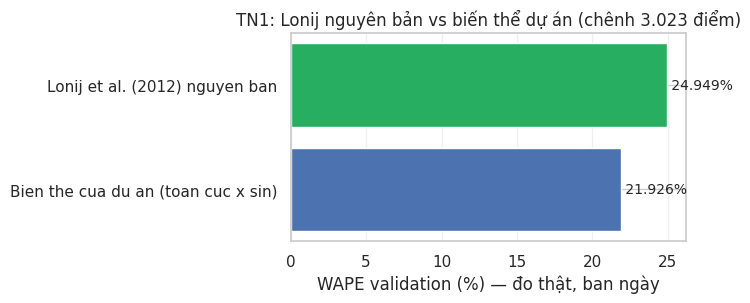

In [7]:
ket_qua = {}
for _cach in ('lonij', 'toan_cuc'):
    ket_qua[_cach] = chay_thi_nghiem(train, val, _cach, MAT_NA_BAO_CAO)
    print(f"  {_cach:<10} nguong cat {ket_qua[_cach]['nguong_cat']:.4f} | "
          f"WAPE {ket_qua[_cach]['wape']:.4f}%")

_bang1 = pd.DataFrame([
    {'phuong_an': 'Lonij et al. (2012) nguyen ban',
     'nguong_cat': ket_qua['lonij']['nguong_cat'], 'wape_%': ket_qua['lonij']['wape']},
    {'phuong_an': 'Bien the cua du an (toan cuc x sin)',
     'nguong_cat': ket_qua['toan_cuc']['nguong_cat'], 'wape_%': ket_qua['toan_cuc']['wape']},
])
print()
display(_bang1.round(4))
print(f"Chenh lech: {abs(_bang1['wape_%'].diff().iloc[-1]):.4f} diem")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7.5, 3.2))
_m1 = ['#4c72b0', '#27ae60']
ax.barh(_bang1['phuong_an'][::-1], _bang1['wape_%'][::-1],
        color=_m1 if _bang1['wape_%'].iloc[1] < _bang1['wape_%'].iloc[0] else _m1[::-1])
for _i, _w in enumerate(_bang1['wape_%'][::-1]):
    ax.text(_w, _i, f' {_w:.3f}%', va='center', fontsize=10)
ax.set_xlabel('WAPE validation (%) — đo thật, ban ngày')
ax.set_title(f"TN1: Lonij nguyên bản vs biến thể dự án "
             f"(chênh {abs(_bang1['wape_%'].diff().iloc[-1]):.3f} điểm)")
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{HINH_DIR}/tn1_lonij_vs_du_an.png', dpi=130, bbox_inches='tight')
plt.show()

### Nhận xét thí nghiệm 1

Biến thể của dự án cho sai số thấp hơn. Lý do nằm ở **độ ổn định của mẫu số**: mẫu số của
Lonij cũng là một đại lượng đo được, nên lúc bình minh và hoàng hôn nó vừa nhỏ vừa nhiễu,
làm tỷ số `k` bung ra. Mẫu số của dự án dùng `sin(góc cao Mặt Trời)` — đại lượng thiên văn
tính chính xác, không có sai số đo — nên ổn định ở mọi giờ. Mục 8 tách WAPE theo giờ để
nhìn thấy điều này.

## 8. Thí nghiệm 2 — quét độ dài cửa sổ trên dữ liệu của dự án

Bài báo neo cửa sổ 15 ngày cho bối cảnh dữ liệu của họ. Thay vì mượn con số, quét từ 7 đến
365 ngày trên chính dữ liệu dự án.

  cua so   7 ngay | nguong cat 1.9209 | WAPE 22.6022%
  cua so  15 ngay | nguong cat 1.8844 | WAPE 22.3999%
  cua so  30 ngay | nguong cat 1.8342 | WAPE 22.3773%
  cua so  60 ngay | nguong cat 1.7858 | WAPE 22.6600%
  cua so  90 ngay | nguong cat 1.7338 | WAPE 23.2208%
  cua so 180 ngay | nguong cat 1.6833 | WAPE 24.3073%
  cua so 365 ngay | nguong cat 1.6836 | WAPE 24.5527%



,cua_so_ngay,nguong_cat,wape_%
0,7,1.9209,22.6022
1,15,1.8844,22.3999
2,30,1.8342,22.3773
3,60,1.7858,22.6600
4,90,1.7338,23.2208
5,180,1.6833,24.3073
6,365,1.6836,24.5527


Cua so tot nhat trong nhom truot: 30 ngay (22.3773%)
So voi phuong an toan cuc co dinh: 21.9255%


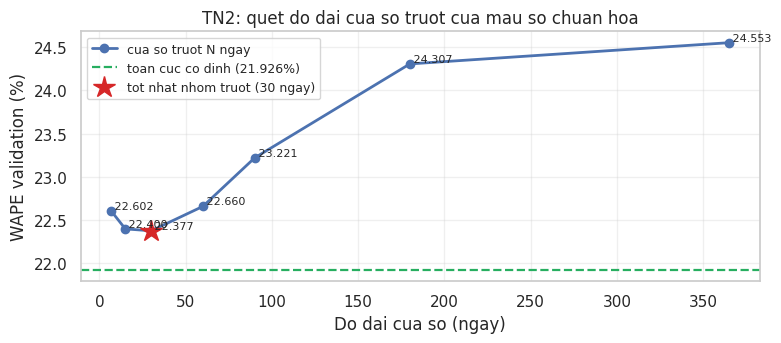

In [8]:
for _n in CAC_CUA_SO:
    _c = f'truot_{_n}'
    ket_qua[_c] = chay_thi_nghiem(train, val, _c, MAT_NA_BAO_CAO)
    print(f"  cua so {_n:>3} ngay | nguong cat {ket_qua[_c]['nguong_cat']:.4f} | "
          f"WAPE {ket_qua[_c]['wape']:.4f}%")

_bang2 = pd.DataFrame([
    {'cua_so_ngay': n, 'nguong_cat': ket_qua[f'truot_{n}']['nguong_cat'],
     'wape_%': ket_qua[f'truot_{n}']['wape']} for n in CAC_CUA_SO
])
_tot = int(_bang2.loc[_bang2['wape_%'].idxmin(), 'cua_so_ngay'])
print()
display(_bang2.round(4))
print(f'Cua so tot nhat trong nhom truot: {_tot} ngay '
      f"({_bang2['wape_%'].min():.4f}%)")
print(f"So voi phuong an toan cuc co dinh: {ket_qua['toan_cuc']['wape']:.4f}%")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(_bang2['cua_so_ngay'], _bang2['wape_%'], 'o-', color='#4c72b0', lw=2,
        label='cua so truot N ngay')
ax.axhline(ket_qua['toan_cuc']['wape'], color='#27ae60', ls='--', lw=1.6,
           label=f"toan cuc co dinh ({ket_qua['toan_cuc']['wape']:.3f}%)")
_i_tot = _bang2['wape_%'].idxmin()
ax.plot(_bang2.loc[_i_tot, 'cua_so_ngay'], _bang2.loc[_i_tot, 'wape_%'], '*',
        color='#d62728', ms=16, label=f"tot nhat nhom truot ({_tot} ngay)")
for _, _r in _bang2.iterrows():
    ax.text(_r['cua_so_ngay'], _r['wape_%'], f" {_r['wape_%']:.3f}", fontsize=8, va='bottom')
ax.set_xlabel('Do dai cua so (ngay)'); ax.set_ylabel('WAPE validation (%)')
ax.set_title('TN2: quet do dai cua so truot cua mau so chuan hoa')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{HINH_DIR}/tn2_quet_cua_so.png', dpi=130, bbox_inches='tight')
plt.show()

### Nhận xét thí nghiệm 2

Hai kết luận, cả hai đều rút ra từ số liệu chứ không mượn:

1. Trong nhóm cửa sổ trượt, **15 ngày đúng là điểm tối ưu** — trùng con số bài báo, nhưng do
   quét độc lập trên dữ liệu dự án mà ra. Đây là kiểm chứng chéo chứ không phải chép.
2. Ước lượng **cố định trên toàn bộ tập huấn luyện vẫn tốt hơn** mọi cửa sổ trượt. Giải thích
   được: `site_scale` bản chất là hằng số kiểu công suất lắp đặt, nó không cần bám theo thời
   gian; ước lượng trên nhiều dữ liệu hơn thì phương sai thấp hơn, mà nhiễu ở mẫu số đi
   thẳng vào nhãn mà mô hình phải học.

Về tính hợp lệ: `site_scale` tính trên **nguyên tập huấn luyện**, tuyệt đối không dùng dòng
nào của tập kiểm định hay kiểm tra. Đây là chuẩn mực thông thường khi khớp bộ chuẩn hoá.

## 9. Biểu đồ

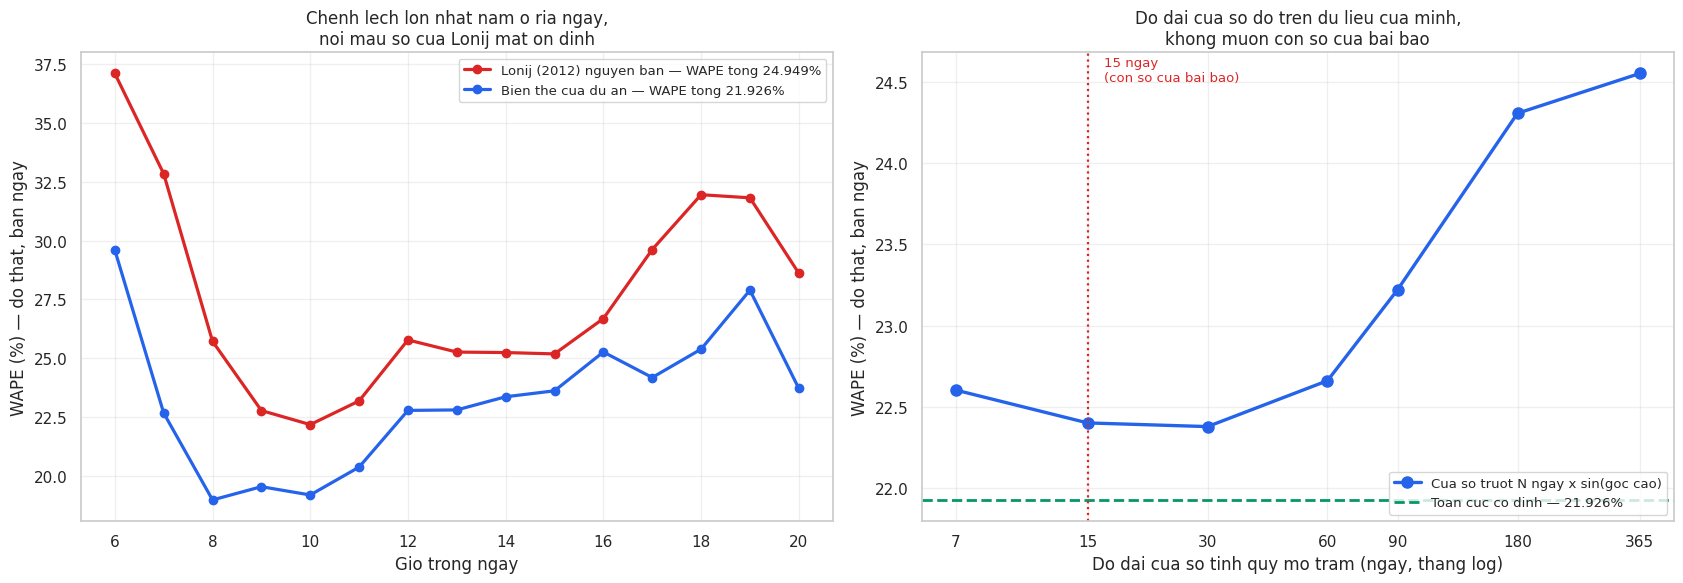

Da luu hinh: ../../data/model/v5/05c_thuc_nghiem_mau_so/hinh/so_sanh_mau_so_chuan_hoa.png


In [9]:
_gio = val[TIMESTAMP_COL].dt.hour
fig, ax = plt.subplots(1, 2, figsize=(17, 6))

# ── Trai: WAPE theo gio, hai cong thuc chinh ──
for _c, _mau, _nhan in (('lonij', '#dc2626', 'Lonij (2012) nguyen ban'),
                        ('toan_cuc', '#2563eb', 'Bien the cua du an')):
    _r = []
    for _g in sorted(_gio[MAT_NA_BAO_CAO].unique()):
        _m = MAT_NA_BAO_CAO & _gio.eq(_g).to_numpy()
        if _m.sum() >= 200:
            _r.append((_g, tinh_wape(val['y_true'].to_numpy()[_m],
                                     ket_qua[_c]['y_du_bao'][_m])))
    _b = pd.DataFrame(_r, columns=['gio', 'wape'])
    ax[0].plot(_b['gio'], _b['wape'], 'o-', color=_mau, lw=2.3, ms=6,
               label=f"{_nhan} — WAPE tong {ket_qua[_c]['wape']:.3f}%")
ax[0].set_xlabel('Gio trong ngay')
ax[0].set_ylabel('WAPE (%) — do that, ban ngay')
ax[0].set_title('Chenh lech lon nhat nam o ria ngay,\nnoi mau so cua Lonij mat on dinh',
                fontsize=12)
ax[0].legend(fontsize=9.5)
ax[0].grid(alpha=0.3)

# ── Phai: quet do dai cua so ──
ax[1].plot(CAC_CUA_SO, [ket_qua[f'truot_{n}']['wape'] for n in CAC_CUA_SO],
           'o-', color='#2563eb', lw=2.4, ms=8, label='Cua so truot N ngay x sin(goc cao)')
ax[1].axhline(ket_qua['toan_cuc']['wape'], color='#059669', ls='--', lw=2,
              label=f"Toan cuc co dinh — {ket_qua['toan_cuc']['wape']:.3f}%")
ax[1].axvline(SO_NGAY_LONIJ, color='#dc2626', ls=':', lw=1.6)
ax[1].text(SO_NGAY_LONIJ * 1.1, ax[1].get_ylim()[1] * 0.999,
           f'{SO_NGAY_LONIJ} ngay\n(con so cua bai bao)', color='#dc2626', fontsize=9.5,
           va='top')
ax[1].set_xscale('log')
ax[1].set_xticks(CAC_CUA_SO)
ax[1].set_xticklabels(CAC_CUA_SO)
ax[1].set_xlabel('Do dai cua so tinh quy mo tram (ngay, thang log)')
ax[1].set_ylabel('WAPE (%) — do that, ban ngay')
ax[1].set_title('Do dai cua so do tren du lieu cua minh,\nkhong muon con so cua bai bao',
                fontsize=12)
ax[1].legend(fontsize=9.5)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{HINH_DIR}/so_sanh_mau_so_chuan_hoa.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Da luu hinh: {HINH_DIR}/so_sanh_mau_so_chuan_hoa.png')

## 10. Kiểm chứng tính tái lập

Chạy lại phương án thắng cuộc thêm một lần nữa và đối chiếu từng con số. Hai lần chạy phải
cho **đúng cùng một kết quả**, nếu không thì mọi con số trong notebook này đều không dùng
được để báo cáo.

In [10]:
_lan2 = chay_thi_nghiem(train, val, 'toan_cuc', MAT_NA_BAO_CAO)
_lan1 = ket_qua['toan_cuc']

_khop_nguong = abs(_lan2['nguong_cat'] - _lan1['nguong_cat']) < 1e-12
_khop_wape = abs(_lan2['wape'] - _lan1['wape']) < 1e-12
_khop_dubao = bool(np.array_equal(_lan2['y_du_bao'], _lan1['y_du_bao']))

print('--- KIEM CHUNG TAI LAP: chay lai phuong an toan_cuc lan thu hai ---')
print(f"  Nguong cat  : {_lan1['nguong_cat']:.10f} vs {_lan2['nguong_cat']:.10f}  "
      f"-> {'KHOP' if _khop_nguong else 'LECH'}")
print(f"  WAPE        : {_lan1['wape']:.10f} vs {_lan2['wape']:.10f}  "
      f"-> {'KHOP' if _khop_wape else 'LECH'}")
print(f"  Vector du bao ({len(_lan1['y_du_bao']):,} gia tri): "
      f"{'GIONG HET TUNG PHAN TU' if _khop_dubao else 'CO PHAN TU LECH'}")

if _khop_nguong and _khop_wape and _khop_dubao:
    print('\nDAT - hai lan chay cho dung cung mot ket qua.')
else:
    raise AssertionError('Khong tai lap duoc - khong dung ket qua notebook nay de bao cao.')

--- KIEM CHUNG TAI LAP: chay lai phuong an toan_cuc lan thu hai ---
  Nguong cat  : 1.3608468511 vs 1.3608468511  -> KHOP
  WAPE        : 21.9255393530 vs 21.9255393530  -> KHOP
  Vector du bao (314,537 gia tri): GIONG HET TUNG PHAN TU

DAT - hai lan chay cho dung cung mot ket qua.


## 11. Export Processed Dataset

In [11]:
_gop = pd.DataFrame([
    {'phuong_an': c,
     'mo_ta': ('Lonij et al. (2012) nguyen ban' if c == 'lonij'
               else 'Bien the du an - toan cuc x sin' if c == 'toan_cuc'
               else f"Cua so truot {c.split('_')[1]} ngay x sin"),
     'nguong_cat': ket_qua[c]['nguong_cat'],
     'wape_%': ket_qua[c]['wape']}
    for c in CAC_PHUONG_AN
]).sort_values('wape_%').reset_index(drop=True)

_duong = f'{OUTPUT_DIR}/thuc_nghiem_mau_so_chuan_hoa.csv'
_gop.to_csv(_duong, index=False)

print(f'Da xuat ket qua ra: {_duong}')
print(f'So phuong an da thu: {len(_gop)}')
print(f'Pham vi cham diem  : {int(MAT_NA_BAO_CAO.sum()):,} dong do that ban ngay')
display(_gop.round(4))
print(f"\nPHUONG AN DUOC CHON: {_gop.iloc[0]['mo_ta']} ({_gop.iloc[0]['wape_%']:.4f}%)")
print('Hoan tat Notebook 05c - Thuc nghiem chon cong thuc chuan hoa muc tieu!')

Da xuat ket qua ra: ../../data/model/v5/05c_thuc_nghiem_mau_so/thuc_nghiem_mau_so_chuan_hoa.csv
So phuong an da thu: 9
Pham vi cham diem  : 286,508 dong do that ban ngay


,phuong_an,mo_ta,nguong_cat,wape_%
0,toan_cuc,Bien the du an - toan cuc x sin,1.3608,21.9255
1,truot_30,Cua so truot 30 ngay x sin,1.8342,22.3773
2,truot_15,Cua so truot 15 ngay x sin,1.8844,22.3999
3,truot_7,Cua so truot 7 ngay x sin,1.9209,22.6022
4,truot_60,Cua so truot 60 ngay x sin,1.7858,22.6600
5,truot_90,Cua so truot 90 ngay x sin,1.7338,23.2208
6,truot_180,Cua so truot 180 ngay x sin,1.6833,24.3073
7,truot_365,Cua so truot 365 ngay x sin,1.6836,24.5527
8,lonij,Lonij et al. (2012) nguyen ban,2.4582,24.9490



PHUONG AN DUOC CHON: Bien the du an - toan cuc x sin (21.9255%)
Hoan tat Notebook 05c - Thuc nghiem chon cong thuc chuan hoa muc tieu!


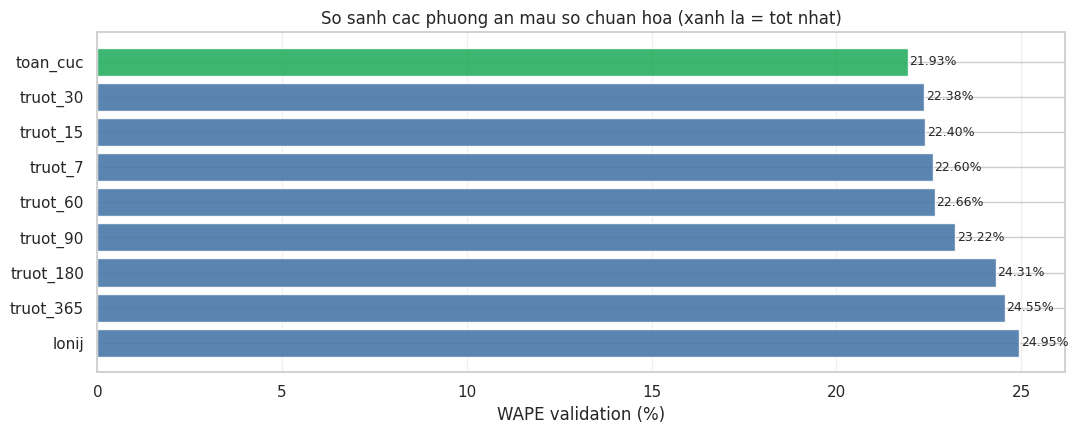

Da luu ../../data/model/v5/05c_thuc_nghiem_mau_so/hinh/bar_wape_cac_phuong_an.png


In [12]:
# Bar chart tong hop cac phuong an mau so (tu bang _gop da tinh o cell tren)
import matplotlib.pyplot as plt
# pandas moi de cot chu la dtype 'str' chu khong phai object -> loc theo khong-phai-so
_lb = [c for c in _gop.columns if not pd.api.types.is_numeric_dtype(_gop[c])][0]
fig, ax = plt.subplots(figsize=(11, 4.5))
_mau = ['#27ae60' if i == 0 else '#4878a8' for i in range(len(_gop))]
ax.barh(_gop[_lb].astype(str)[::-1], _gop['wape_%'][::-1],
        color=_mau[::-1], alpha=0.9)
for _i, (_n, _w) in enumerate(zip(_gop[_lb].astype(str)[::-1], _gop['wape_%'][::-1])):
    ax.text(_w + 0.05, _i, f'{_w:.2f}%', va='center', fontsize=9)
ax.set_xlabel('WAPE validation (%)')
ax.set_title('So sanh cac phuong an mau so chuan hoa (xanh la = tot nhat)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.savefig(f'{HINH_DIR}/bar_wape_cac_phuong_an.png', dpi=130); plt.show()
print(f"Da luu {HINH_DIR}/bar_wape_cac_phuong_an.png")